In [1]:
%matplotlib widget
import mcstasscript as ms

trex = ms.McStas_instr(
    "TRex",
    author="Bing Li",
    origin="DMSC",
    output_path="trex_output",
)

# Instrument definition

In [2]:
L0 = trex.add_parameter(
    "L0",
    value=2.4,
    comment="wavelength in [Å] used to calculate the minimum and maximum wavelength "
    + "for the source component by adding and subtracting a set wavelength",
)

d_Li = trex.add_parameter(
    "d_Li",
    value=0.845,
    comment="wavelength band in [Å] to be simulated",
)

RRM = trex.add_parameter(
    "int",
    "RRM",
    value=18,
    comment="repetition rate multiplication",
)

phase_P = trex.add_parameter(
    "int",
    "phase_P",
    value=0,
    comment="angular offset for the P-Chopper {0: 20deg Opening, 55: 35deg Opening}",
)


trex.add_parameter(
    "int",
    "mod_type",
    value=1,
    comment="this variable determines which moderator type is used "
    + "{0: Thermal moderator, 1: Bispectral moderator, 2: Cold moderator}",
)

bender = trex.add_parameter(
    "int", "bender", value=0, comment="bender out = 0, bender in = 1"
)
b_rot = trex.add_parameter(
    "b_rot", value=-0.5, comment="in [deg], rotation of the cold neutron bender"
)

# Declare section

In [3]:
frac = trex.add_declare_var(
    "double",
    "frac",
    comment="Used in the Source component. Defines the statistical fraction of events"
    + "emitted from the cold part of the moderator, the value is determined later in the file"
    + " depending on the moderator type that was chosen",
)
lamb_1 = trex.add_declare_var("double", "lamb_1", comment="Wavelength min in [AA]")
lamb_2 = trex.add_declare_var("double", "lamb_2", comment="Wavelength max in [AA]")

In [4]:
trex.add_declare_var(
    "double",
    "T_offset",
    value=1700.0 * 1e-6,
    comment="Time offset in [s] to shift to the center of long pulse",
)
trex.add_declare_var(
    "double",
    "f",
    value=14.0,
    comment="Source frequency in [Hz]",
)
trex.add_declare_var(
    "double",
    "rTopUpPar",
    value=[0.99, 0.0219, 3.02, 4.0, 0.003],
    array=5,
)
trex.add_declare_var(
    "double",
    "rTopDownPar",
    value=[0.99, 0.0219, 3.02, 4.0, 0.003],
    array=5,
)


Declare variable: 'rTopDownPar' of type double with value: [0.99, 0.0219, 3.02, 4.0, 0.003]. Array with length 5

In [5]:
trex.append_declare("""

double tof_BW1, tof_BW2, tof_P1, tof_P2;

// characteristic wavelength
double v0;

// distances
double L_BW1 = 32;
double L_BW2 = 40;
double L_P1 = 107.95;
double L_P2 = 108.05;

""")

In [6]:
trex.append_declare("""

// BW1 Chopper
double f_BW1;
double radius_BW1;
char theta_pos_BW1[256] = "0";
char theta_width_BW1[256] = "61.4";
double delta_y_BW1;
double delay_BW1; //time delay
double nslits_BW1;


// BW2 Chopper
double f_BW2;
double radius_BW2;
char theta_pos_BW2[256] = "0";
char theta_width_BW2[256] = "63.3";
double delta_y_BW2;
double delay_BW2; //time delay
double nslits_BW2;

// P1 Chopper
double f_P1;
double radius_P1;
char theta_pos_P1[256] = "0 -55 -180 -235";
char theta_width_P1[256] = "2 35 2 35";
double delta_y_P1;
double delay_P1; //time delay
double nslits_P1;
double phase_P1;// angular delay

double theta_pos_P1_HR = 0;
double theta_pos_P1_HF = -55;
double theta_width_P1_HR = 20;
double theta_width_P1_HF = 35;
double delay_P1_HR; //time delay
double delay_P1_HF; //time delay

// P2 Chopper
double f_P2;
double radius_P2;
char theta_pos_P2[256] = "0 -55 -180 -235";
char theta_width_P2[256] = "2 35 2 35";
double delta_y_P2;
double delay_P2; //time delay
double nslits_P2;
double phase_P2;// angular delay

double theta_pos_P2_HR = 0;
double theta_pos_P2_HF = -55;
double theta_width_P2_HR = 20;
double theta_width_P2_HF = 35;
double delay_P2_HR; //time delay
double delay_P2_HF; //time delay


""")

# Initialize section

In [7]:
trex.append_initialize("""
// Source type
switch (mod_type)
	{
	case 0: {frac = 0.0; break;} // Thermal moderator
	case 1: {frac = 0.5; break;} // Bispectral moderator
	case 2: {frac = 1.0; break;} // Cold moderator
	}
// Source parameters
lamb_1 = L0-d_Li*1.1;
lamb_2 = L0+d_Li*1.1;
""")
trex.append_initialize('printf("lamb_1: %g \\n", lamb_1);')
trex.append_initialize('printf("lamb_2: %g \\n", lamb_2);')
# // Source parameters
# 	vi = 2*PI*K2V/Li;
# 	v1 = 2*PI*K2V/lamb_1;   // slowest neutron
# 	v2 = 2*PI*K2V/lamb_2;   // fastest neutron

In [8]:
trex.append_initialize("""
// frequencies
f_BW1 = f;
f_BW2 = f;
f_P1 = RRM*f*0.75;
f_P2 = -f_P1;

// characteristic wavelength 

v0 = 2*PI*K2V/L0;       // speed center neutron


// time of flight and chopper phases
tof_BW1 = T_offset + L_BW1/v0;
tof_BW2 = T_offset + L_BW2/v0;
tof_P1 = T_offset + L_P1/v0;
tof_P2 = T_offset + L_P2/v0;

/* Chopper parameters */

// BW1 Chopper
radius_BW1 = 0.35;
delta_y_BW1 = -0.3075;
delay_BW1 = tof_BW1; // time delay
nslits_BW1 = 1;

// BW2 Chopper
radius_BW2 = 0.35;
delta_y_BW2 = delta_y_BW1;
delay_BW2 = tof_BW2; // time delay
nslits_BW2 = 1;

// P1 Chopper
radius_P1 = 0.35;
delta_y_P1 = 0.305;
delay_P1 = tof_P1; //time delay#
nslits_P1 = 4;
phase_P1 = phase_P;// angular delay

delay_P1_HR = tof_P1 + theta_pos_P1_HR/f_P1/360; //time delay
delay_P1_HF = tof_P1 + theta_pos_P1_HF/f_P1/360; //time delay

// P2 Chopper
radius_P2 = 0.35;
delta_y_P2 = delta_y_P1;
delay_P2 = tof_P2; //time delay
nslits_P2 = 4;
phase_P2 = phase_P;// angular delay

delay_P2_HR = tof_P2 + theta_pos_P2_HR/f_P2/360; //time delay
delay_P2_HF = tof_P2 + theta_pos_P2_HF/f_P2/360; //time delay

""")

In [9]:
trex.show_variables()

DECLARE VARIABLES 
type    variable name  array length  value                             
---------------------------------------------------------------------
double  frac                                                           
double  lamb_1                                                         
double  lamb_2                                                         
double  T_offset                     0.0017                            
double  f                            14.0                              
double  rTopUpPar      5             [0.99, 0.0219, 3.02, 4.0, 0.003]  
double  rTopDownPar    5             [0.99, 0.0219, 3.02, 4.0, 0.003]  



In [10]:
trex.show_variables

<bound method McCode_instr.show_variables of <mcstasscript.interface.instr.McStas_instr object at 0x14c267380>>

# Trace section

In [11]:
# https://mcstas.org/download/components/3.7.9/sources/ESS_butterfly.html
source = trex.add_component(name="source", component_name="ESS_butterfly")
source.set_parameters(
    sector='"W"',
    beamline=7,
    yheight=0.03,  # [m], moderator height, 0.03 to 0.06
    cold_frac=frac,
    # target_index not needed if using dist
    dist=2,  # [m], distance to focusing rectange
    focus_xw=0.095,  # [m], size of focusing rectange
    focus_yh=0.035,
    # c_performance: float = 1.0
    # t_performance: float = 1.0
    Lmin=lamb_1,  # in Angstrom
    Lmax=lamb_2,  # in Angstrom
    n_pulses=1,
    acc_power=2,
    tfocus_dist="L_BW1",  # [m], Position of time focusing window along z axis
    tfocus_time="tof_BW1",  # [s], position of time focusing window`
    tfocus_width=0.02,  # [s], width of time focusing window`
)

Source monitors

In [12]:
# --------------------------------------------------------
source_monitor_xy = trex.add_component(
    "source_monitor_xy", "Monitor_nD", AT=[-0.002, 0, 1.8953]
)
source_monitor_xy.set_parameters(
    xwidth=0.1, yheight=0.04, restore_neutron=1, filename='"source_monitor_xy.dat"'
)
source_monitor_xy.options = (
    '"x limits [-0.06:0.06] bins = 100, y limits [-0.03:0.03] bins = 100"'
)
source_monitor_xy.set_comment(
    "Note: -0.002 because guide is asymmetric here (47mm-43mm)/2"
)

# --------------------------------------------------------
source_monitor_div = trex.add_component(
    "source_monitor_div", "Monitor_nD", AT=[0, 0, 1e-4], RELATIVE="PREVIOUS"
)
source_monitor_div.set_parameters(
    xwidth=0.09, yheight=0.03, restore_neutron=1, filename='"source_monitor_div.dat"'
)
source_monitor_div.options = (
    '"hdiv limits [-4.5:4.5] bins = 100, vdiv limits [-2.5:2.5] bins = 100"'
)
# --------------------------------------------------------
source_monitor_lam = trex.add_component(
    "source_monitor_lam", "Monitor_nD", AT=[0, 0, 1e-4], RELATIVE="PREVIOUS"
)
source_monitor_lam.set_parameters(
    xwidth=0.09, yheight=0.03, restore_neutron=1, filename='"source_monitor_lam.dat"'
)
source_monitor_lam.options = '"lambda limits [0.5:7.0] bins = 130"'

In [13]:
for i in range(9):
    if i in (2, 6):
        continue
    guide = trex.add_component(f"guide_{i}", "Guide_anyshape_r")
    guide.set_parameters(geometry=f'"./OFF_files/try{i}.off"')

trex.get_component("guide_0").set_comment("NBOA section")

guide = trex.add_component("guide_10", "Guide_anyshape_r", WHEN="bender==0")
guide.set_parameters(geometry='"./OFF_files/try10.off"')
guide.set_comment("BBGOA: thermal -> guide 10 & 11; cold: bender & guide 11")

In [14]:
# https://mcstas.org/download/components/3.7.9/optics/Pol_bender.html
bender = trex.add_component("bender", "Pol_bender", WHEN="bender==1")
bender.set_AT([-0.017, 0, 5.399])
bender.set_ROTATED([0 + 0.00192, b_rot, 0])
bender.set_parameters(
    xwidth=0.06384,  # [m], with at entrance
    yheight=0.046,  # [m], height at entrance
    length=0.05,  # [m], length along center
    radius=7.2,  # [m], radius of curvature +/- is left/right
    nslit=425,  # num of slits
    d=1e-6,  # [m], width of spacers
    endFlat=0,  # entrance/exit planes NOT parallel
    drawOption=2,  # ?
    # Top mirror Parameters for spin up/down standard reflectivity function
    # StdReflecFunc = {R0, Qc, alpha, m, W}
    # Bot -> Top, Left -> Top, Right -> Left
    rTopUpPar="rTopUpPar",
    rTopDownPar="rTopDownPar",
)

bender.set_comment(
    "bender: 63.84mm x 46mm x 50mm (WxHxL), 0.15mm Si channels/ NiTi m=4 curve=7.2m"
)

In [15]:
guide = trex.add_component("guide_11", "Guide_anyshape_r")
guide.set_parameters(geometry='"./OFF_files/try11.off"')

In [16]:
# https://mcstas.org/download/components/3.7.9/optics/Slit.html
slit = trex.add_component("slit", "Slit", AT=[-0.017, 0, 5.915])
slit.set_parameters(
    xwidth=0.06,  # [m]
    yheight=0.046,  # [m]
)

insert monitors

In [17]:
# --------------------------------------------------------
insert_monitor_xy = trex.add_component(
    "insert_monitor_xy", "Monitor_nD", AT=[0, 0, 1e-4], RELATIVE="PREVIOUS"
)
insert_monitor_xy.set_parameters(
    xwidth=0.06, yheight=0.046, restore_neutron=1, filename='"insert_monitor_xy.dat"'
)
insert_monitor_xy.options = (
    #'"x limits [-0.03:0.03] bins = 100, y limits [-0.023:0.023] bins = 100"'
    '"x limits [-0.04:0.04] bins = 100, y limits [-0.033:0.033] bins = 100"'
)
# --------------------------------------------------------
insert_monitor_div = trex.add_component(
    "insert_monitor_div", "Monitor_nD", AT=[0, 0, 1e-4], RELATIVE="PREVIOUS"
)
insert_monitor_div.set_parameters(
    xwidth=0.06, yheight=0.046, restore_neutron=1, filename='"insert_monitor_div.dat"'
)
insert_monitor_div.options = (
    '"hdiv limits [-2.0:2.0] bins = 201, vdiv limits [-1.0:1.0] bins = 201"'
)
# --------------------------------------------------------
insert_monitor_lam = trex.add_component(
    "insert_monitor_lam", "Monitor_nD", AT=[0, 0, 1e-4], RELATIVE="PREVIOUS"
)
insert_monitor_lam.set_parameters(
    xwidth=0.06, yheight=0.046, restore_neutron=1, filename='"insert_monitor_lam.dat"'
)
insert_monitor_lam.options = '"lambda limits [0.5:7.0] bins = 130"'
# --------------------------------------------------------
inset_monitor_ToF = trex.add_component(
    "inset_monitor_ToF", "Monitor_nD", AT=[0, 0, 1e-4], RELATIVE="PREVIOUS"
)
inset_monitor_ToF.set_parameters(
    xwidth=0.07, yheight=0.07, restore_neutron=1, filename='"inset_monitor_ToF.dat"'
)
inset_monitor_ToF.options = '"t limits [0.0:0.020] bins = 20000"'

In [18]:
for i in range(13, 23):
    if i in (17, 21):
        continue
    guide = trex.add_component(f"guide_{i}", "Guide_anyshape_r")
    guide.set_parameters(geometry=f'"./OFF_files/try{i}.off"')

trex.get_component("guide_13").set_comment("In-bunker section plus a little bit")

In [19]:
for i in range(23, 33):
    if i in (26, 31):
        continue
    guide = trex.add_component(f"guide_{i}", "Guide_anyshape_r")
    guide.set_parameters(geometry=f'"./OFF_files/try{i}.off"')

In [20]:
for i in range(33, 48):
    if i in (35, 38, 43):
        continue
    guide = trex.add_component(f"guide_{i}", "Guide_anyshape_r")
    guide.set_parameters(geometry=f'"./OFF_files/try{i}.off"')

trex.get_component("guide_39").set_comment("Bunker wall insert starts here")

In [21]:
BW_Chopper_1 = trex.add_component(
    "BW_Chopper_1",
    "MultiDiskChopper",
    AT=[0.011348994153930106, 0.0, 32.0],
    ROTATED=[0, 0.124542024141650, 0],
    comment="Bandwidth chopper 1",
)

BW_Chopper_1.set_parameters(
    slit_center="theta_pos_BW1",
    slit_width="theta_width_BW1",
    radius="radius_BW1",
    delta_y="delta_y_BW1",
    nu="f_BW1",
    delay="delay_BW1",
    nslits="nslits_BW1",
)

B1 monitors

In [22]:
# --------------------------------------------------------
# B1_monitor_flux = trex.add_component(
#     "B1_monitor_flux", "Monitor_nD", AT=[0, 0, 1e-6], RELATIVE="PREVIOUS"
# )
# B1_monitor_flux.set_parameters(
#     xwidth=0.06, yheight=0.084, restore_neutron=1, filename='"B1_flux.dat"'
# )
# B1_monitor_flux.options = '"flux bins=1"'
# --------------------------------------------------------
B1_monitor_xy = trex.add_component(
    "B1_monitor_xy", "Monitor_nD", AT=[0, 0, 1e-4], RELATIVE="PREVIOUS"
)
B1_monitor_xy.set_parameters(
    xwidth=0.07, yheight=0.09, restore_neutron=1, filename='"BW1_monitor_xy.dat"'
)
B1_monitor_xy.options = (
    '"x limits [-0.035:0.035] bins = 100, y limits [-0.045:0.045] bins = 100"'
)
# --------------------------------------------------------
B1_monitor_lam = trex.add_component(
    "B1_monitor_lam", "Monitor_nD", AT=[0, 0, 1e-4], RELATIVE="PREVIOUS"
)
B1_monitor_lam.set_parameters(
    xwidth=0.07, yheight=0.09, restore_neutron=1, filename='"BW1_monitor_lam.dat"'
)
B1_monitor_lam.options = '"lambda limits [0.5:10.0] bins = 130"'
# --------------------------------------------------------
BW1_monitor_ToF = trex.add_component(
    "BW1_monitor_ToF", "Monitor_nD", AT=[0, 0, 1e-4], RELATIVE="PREVIOUS"
)
BW1_monitor_ToF.set_parameters(
    xwidth=0.07, yheight=0.09, restore_neutron=1, filename='"BW1_monitor_ToF.dat"'
)
BW1_monitor_ToF.options = '"t limits [0.0:0.050] bins = 20000"'
# TODO options=setBW1,

In [23]:
for i in range(49, 56):
    guide = trex.add_component(f"guide_{i}", "Guide_anyshape_r")
    guide.set_parameters(geometry=f'"./OFF_files/try{i}.off"')

In [24]:
BW_Chopper_2 = trex.add_component(
    "BW_Chopper_2",
    "MultiDiskChopper",
    AT=[0.03140505829452013, 0.0, 40.0],
    ROTATED=[0, 0.162739331227240, 0],
    comment="Bandwidth chopper 2 ",
)

BW_Chopper_2.set_parameters(
    slit_center="theta_pos_BW2",
    slit_width="theta_width_BW2",
    radius="radius_BW2",
    delta_y="delta_y_BW2",
    nu="f_BW2",
    delay="delay_BW2",
    nslits="nslits_BW2",
)

In [25]:
B2_monitor_xy = trex.add_component(
    "B2_monitor_xy", "Monitor_nD", AT=[0, 0, 1e-4], RELATIVE="PREVIOUS"
)
B2_monitor_xy.set_parameters(
    xwidth=0.06, yheight=0.085, restore_neutron=1, filename='"BW2_monitor_xy.dat"'
)
B2_monitor_xy.options = (
    '"x limits [-0.0375:0.0375] bins = 100, y limits [-0.05:0.05] bins = 100"'
)
# --------------------------------------------------------
B2_monitor_lam = trex.add_component(
    "B2_monitor_lam", "Monitor_nD", AT=[0, 0, 1e-4], RELATIVE="PREVIOUS"
)
B2_monitor_lam.set_parameters(
    xwidth=0.06, yheight=0.085, restore_neutron=1, filename='"BW2_monitor_lam.dat"'
)
B2_monitor_lam.options = '"lambda limits [0.5:10.0] bins = 130"'
# --------------------------------------------------------
BW2_monitor_ToF = trex.add_component(
    "BW2_monitor_ToF", "Monitor_nD", AT=[0, 0, 1e-4], RELATIVE="PREVIOUS"
)
BW2_monitor_ToF.set_parameters(
    xwidth=0.06, yheight=0.084, restore_neutron=1, filename='"BW2_monitor_ToF.dat"'
)
BW2_monitor_ToF.options = '"t limits [0.0:0.050] bins = 20000"'
# TODO setBW2

In [26]:
for i in range(57, 102):
    guide = trex.add_component(f"guide_{i}", "Guide_anyshape_r")
    guide.set_parameters(geometry=f'"./OFF_files/try{i}.off"')

In [27]:
# PulseShapingChopper1 = trex.add_component(
#     "PulseShapingChopper1",
#     "MultiDiskChopper",
#     AT=[0.4108460115539497, 0.0, 107.95],
#     ROTATED=[0, 0.430122381481144, 0],
#     comment="/* ---------------------- P-Choppers -------------------- */",
# )

# PulseShapingChopper1.set_parameters(
#     slit_center="theta_pos_P1",
#     slit_width="theta_width_P1",
#     radius="radius_P1",
#     delta_y="delta_y_P1",
#     nu="f_P1",
#     delay="delay_P1",
#     nslits="nslits_P1",
# )

In [ ]:
PulseShapingChopper1_HR = trex.add_component(
    "PulseShapingChopper1_HR",
    "DiskChopper",
    AT=[0.4108460115539497, 0.0, 107.95],
    ROTATED=[0, 0.430122381481144, 180],
    comment="/* ---------------------- P-Choppers -------------------- */",
)
PulseShapingChopper1_HR.set_GROUP("PulseShapingChopper1")

PulseShapingChopper1_HR.set_parameters(
    theta_0="theta_width_P1_HR",
    radius="radius_P1",
    yheight=0.095,
    nu="f_P1",
    delay="delay_P1_HR",
    nslit=2,
)
PulseShapingChopper1_HF = trex.add_component(
    "PulseShapingChopper1_HF",
    "DiskChopper",
    AT=[0.4108460115539497, 0.0, 107.95],
    ROTATED=[0, 0.430122381481144, 180],
    GROUP="PulseShapingChopper1",
)

PulseShapingChopper1_HF.set_parameters(
    theta_0="theta_width_P1_HF",
    radius="radius_P1",
    yheight=0.095,
    nu="f_P1",
    delay="delay_P1_HF",
    nslit=2,
)


In [28]:
# PulseShapingChopper2 = trex.add_component(
#     "PulseShapingChopper2",
#     "MultiDiskChopper",
#     AT=[0.41159673083080733, 0.0, 108.055],
#     ROTATED=[0, 0.430122381481144, 0],
# )

# PulseShapingChopper2.set_parameters(
#     slit_center="theta_pos_P2",
#     slit_width="theta_width_P2",
#     radius="radius_P2",
#     delta_y="delta_y_P2",
#     nu="f_P2",
#     delay="delay_P2",
#     nslits="nslits_P2",
# )

In [29]:
PulseShapingChopper2_HR = trex.add_component(
    "PulseShapingChopper2_HR",
    "DiskChopper",
    AT=[0.41159673083080733, 0.0, 108.055],
    ROTATED=[0, 0.430122381481144, 180],
)
PulseShapingChopper2_HR.set_GROUP("PulseShapingChopper2")

PulseShapingChopper2_HR.set_parameters(
    theta_0="theta_width_P2_HR",
    radius="radius_P2",
    yheight=0.095,
    nu="f_P2",
    delay="delay_P2_HR",
    nslit=2,
)
PulseShapingChopper2_HF = trex.add_component(
    "PulseShapingChopper2_HF",
    "DiskChopper",
    AT=[0.41159673083080733, 0.0, 108.055],
    ROTATED=[0, 0.430122381481144, 180],
    GROUP="PulseShapingChopper2",
)

PulseShapingChopper2_HF.set_parameters(
    theta_0="theta_width_P2_HF",
    radius="radius_P2",
    yheight=0.095,
    nu="f_P2",
    delay="delay_P2_HF",
    nslit=2,
)

In [31]:
P_monitor_ToF = trex.add_component(
    "P_monitor_ToF", "Monitor_nD", AT=[0, 0, 1e-4], RELATIVE="PREVIOUS"
)
P_monitor_ToF.set_parameters(
    xwidth=0.06, yheight=0.084, restore_neutron=1, filename='"P_monitor_tof.dat"'
)
P_monitor_ToF.options = '"t limits [0.04:0.100] bins = 20000"'
# TODO options=setBW1,
# --------------------------------------------------------
P_monitor_lam = trex.add_component(
    "P_monitor_lam", "Monitor_nD", AT=[0, 0, 1e-4], RELATIVE="PREVIOUS"
)
P_monitor_lam.set_parameters(
    xwidth=0.06, yheight=0.085, restore_neutron=1, filename='"P_monitor_lam.dat"'
)
P_monitor_lam.options = '"lambda limits [0.5:10.0] bins = 130"'
# --------------------------------------------------------
P_monitor_ToF_lam = trex.add_component(
    "P_monitor_ToF_lam", "Monitor_nD", AT=[0, 0, 1e-4], RELATIVE="PREVIOUS"
)
P_monitor_ToF_lam.set_parameters(
    xwidth=0.06, yheight=0.084, restore_neutron=1, filename='"P_monitor_tof_lam.dat"'
)
P_monitor_ToF_lam.options = (
    '"t limits [0.04:0.100] bins = 2000 lambda limits [0.5:4.0] bins = 130"'
)

# Check, remove old run and Rerun

In [32]:
try:
    trex.check_for_errors()
except Exception as e:
    print(str(e))

In [33]:
# import os
# import shutil
# shutil.rmtree(os.path.join(os.getcwd(), trex.output_path))

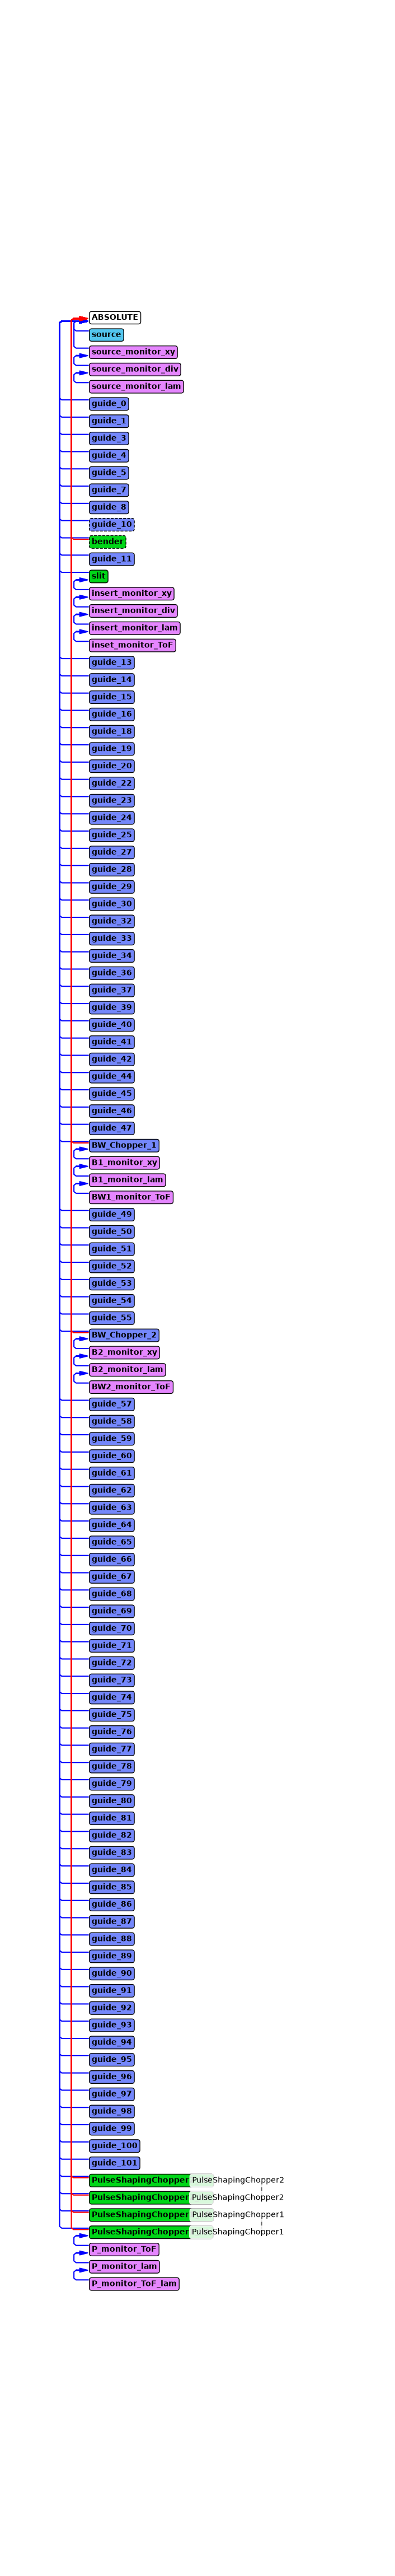

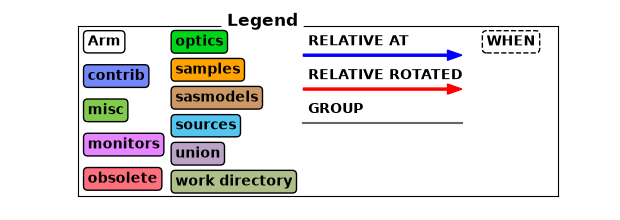

In [36]:
# trex.show_diagram(variable="l", limits=[0.8, 3.5])
trex.show_diagram(analysis=False)

In [35]:
trex.settings(ncount=1e8)  # mpi="auto")
data = trex.backengine()
print(data)

KeyboardInterrupt: 

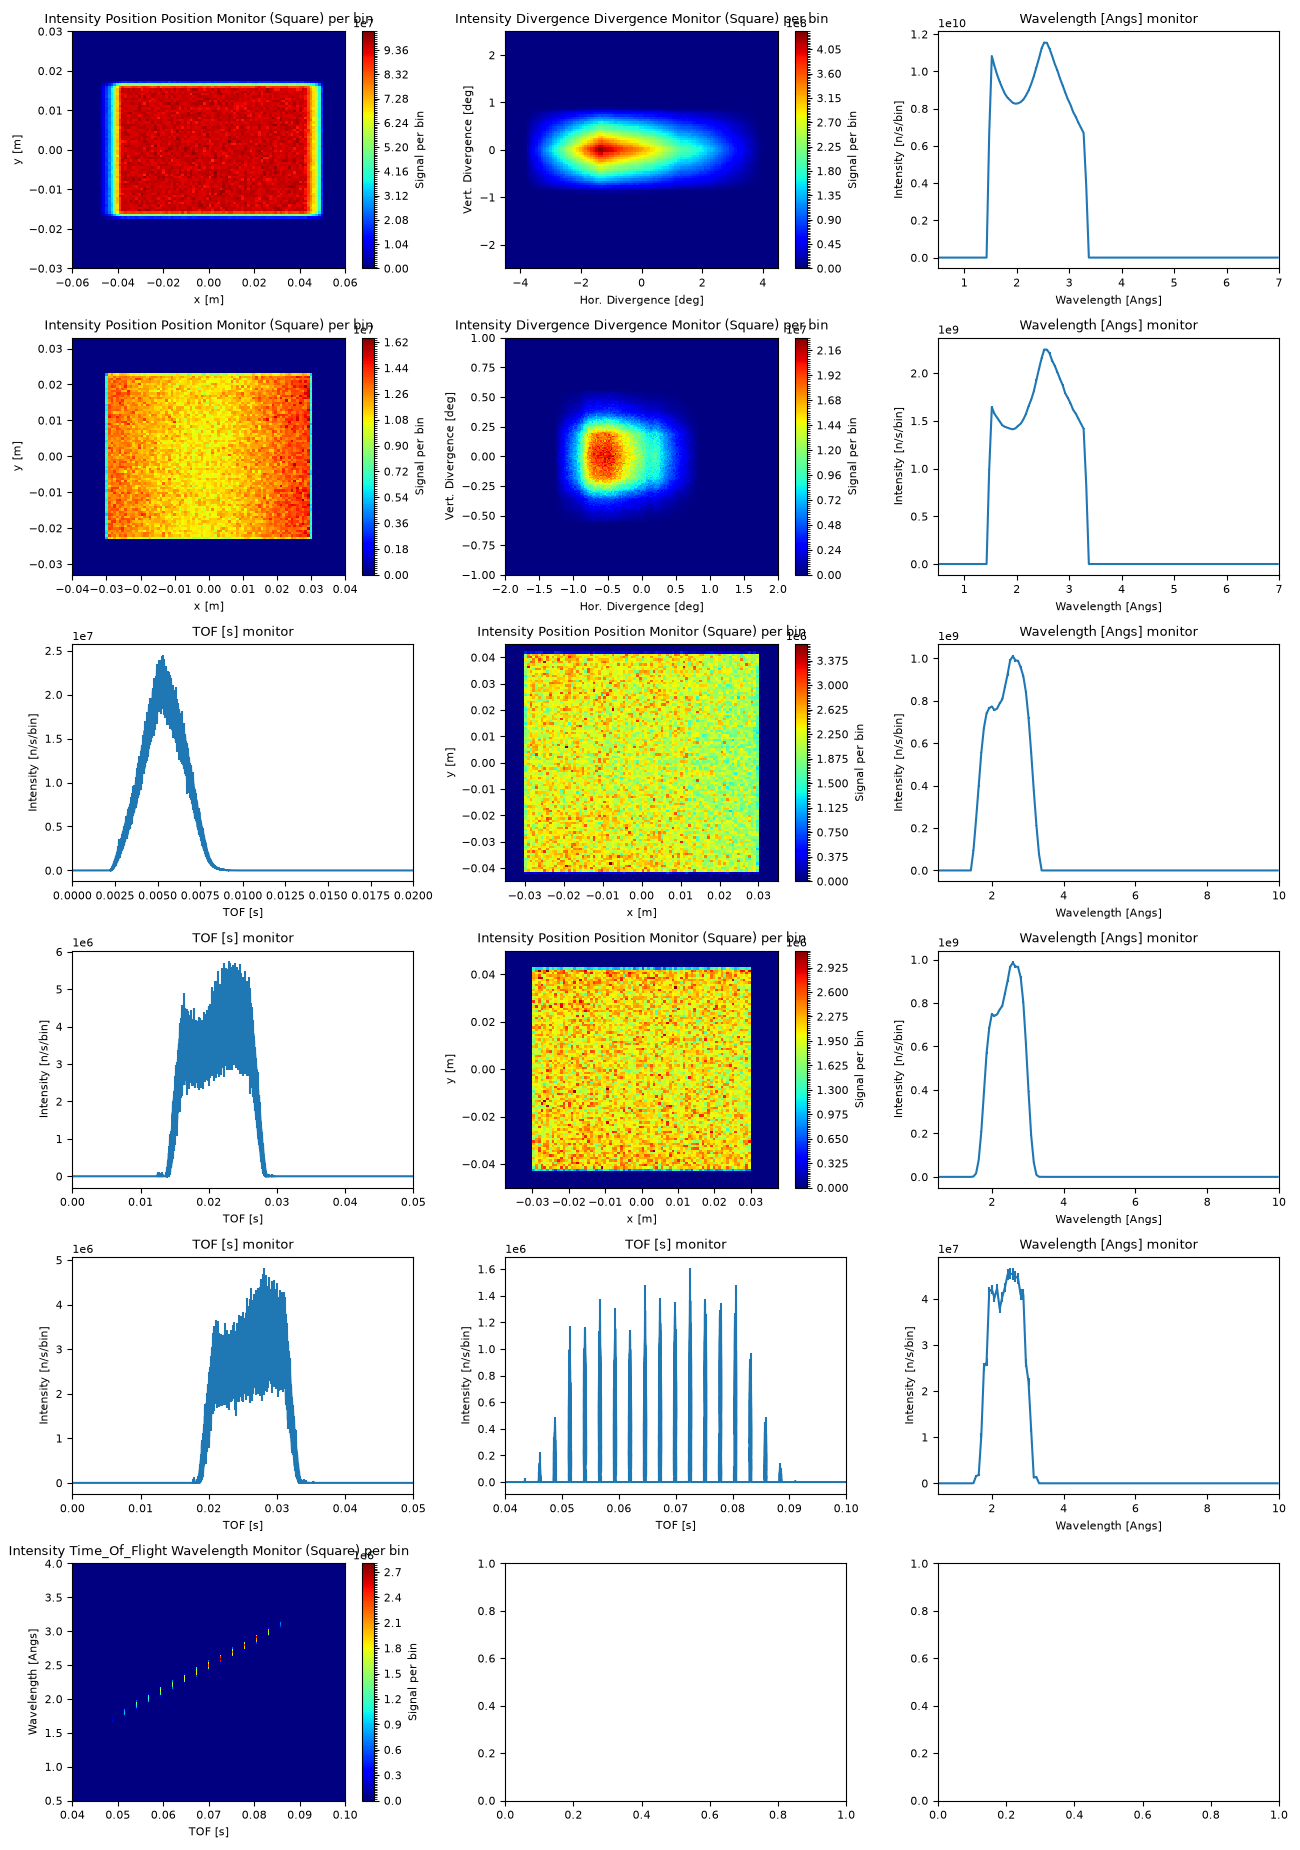

In [ ]:
ms.make_sub_plot(data, fontsize=8)

In [ ]:
trex.show_instrument(backend="pythreejs")